In [1]:
# CELL 1 — Load Data + Preprocessing

import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import OrdinalEncoder, StandardScaler

df = pd.read_csv("../data/processed_diamonds.csv")


# IDEAL clustering features (price removed)
IDEAL_FEATURES = ["carat", "cut", "color", "clarity", "depth", "table", "y", "z", "volume"]

# Keep only the features that exist
features = [f for f in IDEAL_FEATURES if f in df.columns]

missing = [f for f in IDEAL_FEATURES if f not in df.columns]
if missing:
    print("⚠ Missing features:", missing)

X = df[features].copy()

# Identify categorical & numerical
cat_cols = [col for col in ["cut","color","clarity"] if col in features]
num_cols = [col for col in features if col not in cat_cols]

# Ordinal Encoding
cut_order = ['Fair','Good','Very Good','Premium','Ideal']
color_order = ['J','I','H','G','F','E','D']
clarity_order = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

encoder = OrdinalEncoder(
    categories=[cut_order, color_order, clarity_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_cat = pd.DataFrame(
    encoder.fit_transform(X[cat_cols]),
    columns=cat_cols,
    index=X.index
)

# Standard Scaling
scaler = StandardScaler()
X_num = pd.DataFrame(
    scaler.fit_transform(X[num_cols]),
    columns=num_cols,
    index=X.index
)

# Final processed dataset
X_processed = pd.concat([X_num, X_cat], axis=1)

print("Processed Clustering Shape:", X_processed.shape)

# Save encoders for Streamlit
joblib.dump(encoder, "../models/cluster_encoder.pkl")
joblib.dump(scaler, "../models/cluster_scaler.pkl")
print("✔ Encoder & Scaler saved!")


Processed Clustering Shape: (46530, 9)
✔ Encoder & Scaler saved!


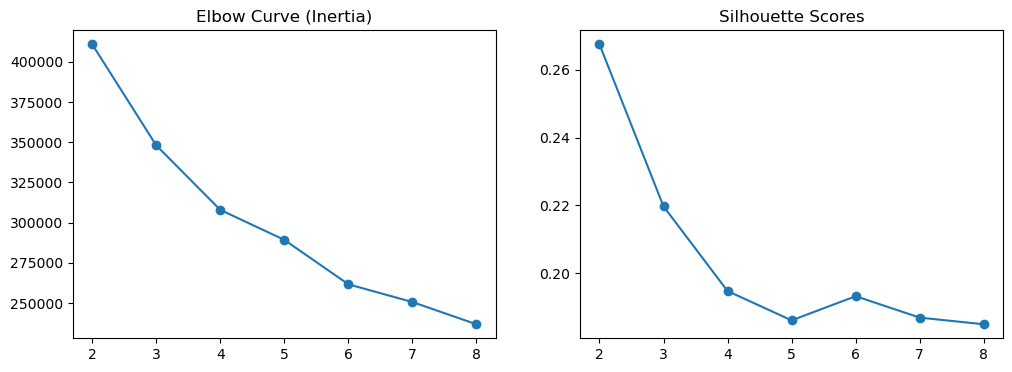

✔ Optimal K = 2
Final Silhouette Score: 0.2675
✔ KMeans model saved!


In [2]:
# CELL 2 — Elbow + Silhouette + Final Model

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

K_range = range(2, 9)
inertia_list = []
silhouette_list = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_processed)
    
    inertia_list.append(km.inertia_)
    score = silhouette_score(X_processed, labels)
    silhouette_list.append(score)

# PLOTS
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow Curve (Inertia)")

plt.subplot(1,2,2)
plt.plot(K_range, silhouette_list, marker='o')
plt.title("Silhouette Scores")
plt.show()

# Choose k automatically = max silhouette score
K_OPTIMAL = K_range[np.argmax(silhouette_list)]
print("✔ Optimal K =", K_OPTIMAL)

# Final model
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_processed)
df["cluster"] = labels

score = silhouette_score(X_processed, labels)
print("Final Silhouette Score:", round(score,4))

# Save model
joblib.dump(kmeans, "../models/best_cluster_model.pkl")
print("✔ KMeans model saved!")


In [3]:
# CELL 3 — Cluster Profiling + Naming

df_temp = df.copy()

# Decode categorical values correctly
df_temp[cat_cols] = encoder.inverse_transform(X_cat)

cluster_summary = df_temp.groupby("cluster").agg({
    "price_inr":"mean",
    "carat":"mean",
    "volume":"mean",
    "cut": lambda x: x.mode()[0],
    "clarity": lambda x: x.mode()[0]
}).sort_values("price_inr", ascending=False)

print("Cluster Profile:")
print(cluster_summary.round(2))


# Auto cluster naming based on average price

cluster_names = {}

highest_price_cluster = cluster_summary["price_inr"].idxmax()
lowest_price_cluster = cluster_summary["price_inr"].idxmin()

for cid in cluster_summary.index:

    if cid == highest_price_cluster:
        cluster_names[cid] = "Premium Diamonds"

    elif cid == lowest_price_cluster:
        cluster_names[cid] = "Affordable Diamonds"

    else:
        cluster_names[cid] = "Mid-range Diamonds"

print("\nAssigned Cluster Names:")
print(cluster_names)

df["cluster_name"] = df["cluster"].map(cluster_names)

joblib.dump(cluster_names, "../models/cluster_names.pkl")

# Save updated dataset with clusters
df.to_csv("../data/processed_diamonds.csv", index=False)

print("✔ Cluster names saved!")
print("✔ Dataset updated with clusters!")

df[["cluster","cluster_name","carat","price_inr"]].sample(10)


Cluster Profile:
         price_inr  carat  volume    cut clarity
cluster                                         
0            12.86   0.70    5.09  Ideal     SI1
1            11.38   0.35    4.20  Ideal     VS2

Assigned Cluster Names:
{0: 'Premium Diamonds', 1: 'Affordable Diamonds'}
✔ Cluster names saved!
✔ Dataset updated with clusters!


,cluster,cluster_name,carat,price_inr
1404,1,Affordable Diamonds,0.500775,12.450022
38953,1,Affordable Diamonds,0.405465,11.880453
41933,1,Affordable Diamonds,0.431782,12.063852
12150,0,Premium Diamonds,0.737164,13.054429
10873,0,Premium Diamonds,0.698135,12.985904
2779,0,Premium Diamonds,0.587787,12.547962
23220,1,Affordable Diamonds,0.270027,10.990887
8260,0,Premium Diamonds,0.741937,12.862675
16261,1,Affordable Diamonds,0.285179,10.862665
16138,0,Premium Diamonds,0.841567,13.307541


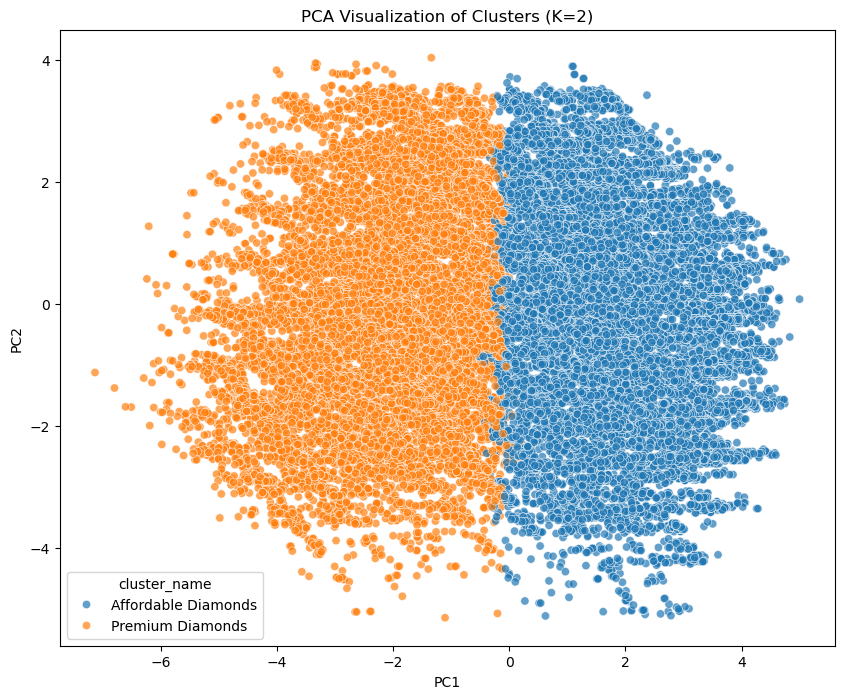

In [4]:
# CELL 4 — PCA Visualization

from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
pca_vals = pca.fit_transform(X_processed)

pca_df = pd.DataFrame(pca_vals, columns=["PC1","PC2"])
pca_df["cluster_name"] = df["cluster_name"]

plt.figure(figsize=(10,8))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue="cluster_name", palette="tab10",
    alpha=0.7
)
plt.title(f"PCA Visualization of Clusters (K={len(cluster_names)})")
plt.show()


In [5]:
print(cluster_names)
print(df["cluster"].value_counts())

{0: 'Premium Diamonds', 1: 'Affordable Diamonds'}
cluster
1    25137
0    21393
Name: count, dtype: int64


In [6]:
joblib.dump(
    cluster_names,
    "../models/cluster_names.pkl"
)

joblib.dump(
    kmeans,
    "../models/best_cluster_model.pkl"
)

['../models/best_cluster_model.pkl']